<a href="https://colab.research.google.com/github/sadeghzadehsadegh/MGCourse/blob/main/DopedDefectedGraphene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Welcome to Machine Learning of Graphene Sheet Stress!")

import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Welcome to Machine Learning of Graphene Sheet Stress!


In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/sadeghzadehsadegh/MGCourse/main/Data/graphene_dataset_with_all_defects.csv"
df = pd.read_csv(url)
df.columns = [    "c_N",    "c_B",    "c_P",    "c_O",    "def_N",    "def_B",    "def_P",    "def_O",    "def_C",    "def_total",
    "E",    "sigmay"]
DopDef = df
display(DopDef.head())
print(DopDef.info())

,c_N,c_B,c_P,c_O,def_N,def_B,def_P,def_O,def_C,def_total,E,sigmay
0,0.032454,0.005138,0.015816,0.010288,0.006038,0.022929,0.019484,0.006918,0.025304,0.080674,275.768231,5.000000
1,0.014493,0.003999,0.003445,0.005042,0.025613,0.022741,0.013956,0.026486,0.028526,0.117322,101.365604,5.000000
2,0.000671,0.001019,0.001260,0.001148,0.002307,0.015586,0.028101,0.008340,0.001640,0.055974,534.532736,52.167830
3,0.000123,0.000844,0.000236,0.000449,0.028648,0.009068,0.003789,0.003232,0.010288,0.055025,584.587138,63.347269
4,0.002289,0.059057,0.017510,0.002471,0.025444,0.017697,0.013018,0.004036,0.026842,0.087037,246.033498,13.594092


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   c_N        2000 non-null   float64
 1   c_B        2000 non-null   float64
 2   c_P        2000 non-null   float64
 3   c_O        2000 non-null   float64
 4   def_N      2000 non-null   float64
 5   def_B      2000 non-null   float64
 6   def_P      2000 non-null   float64
 7   def_O      2000 non-null   float64
 8   def_C      2000 non-null   float64
 9   def_total  2000 non-null   float64
 10  E          2000 non-null   float64
 11  sigmay     2000 non-null   float64
dtypes: float64(12)
memory usage: 187.6 KB
None


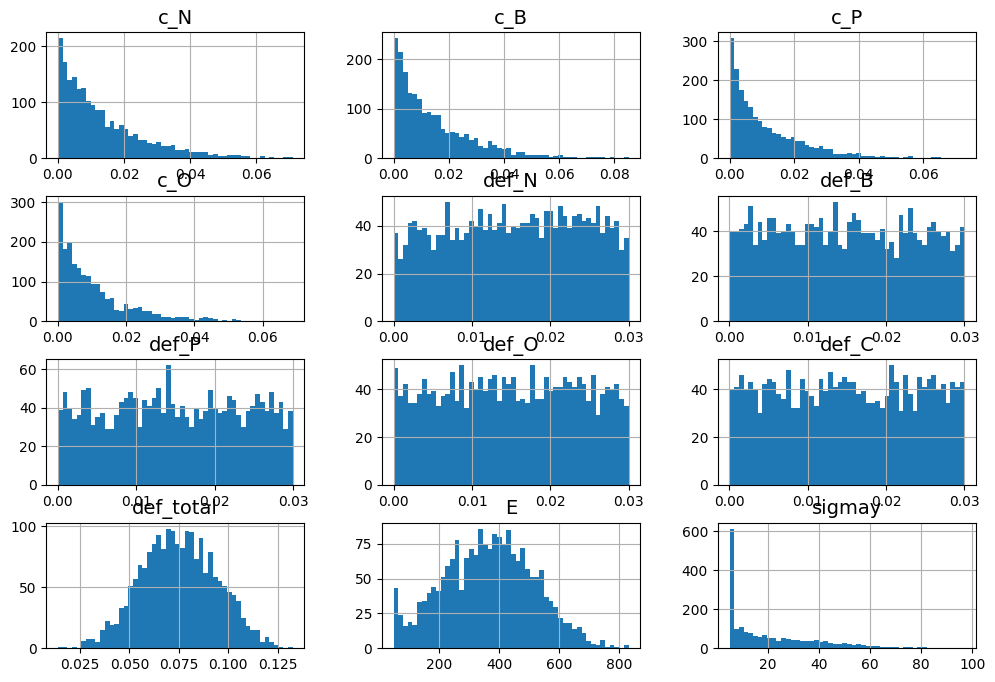

In [ ]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

DopDef.hist(bins=50, figsize=(12, 8))
plt.show()

## Looking for Correlations

In [ ]:
corr_matrix =DopDef.corr(numeric_only=True)
corr_matrix[['E', 'sigmay']].sort_values(by='E', ascending=True)

,E,sigmay
def_total,-0.932391,-0.829646
def_C,-0.476759,-0.420392
def_O,-0.438073,-0.383879
def_B,-0.413184,-0.371604
def_P,-0.408612,-0.348532
def_N,-0.333129,-0.317615
c_O,-0.184912,-0.133884
c_P,-0.184322,-0.143159
c_B,-0.130061,-0.109793
c_N,-0.081442,-0.076516


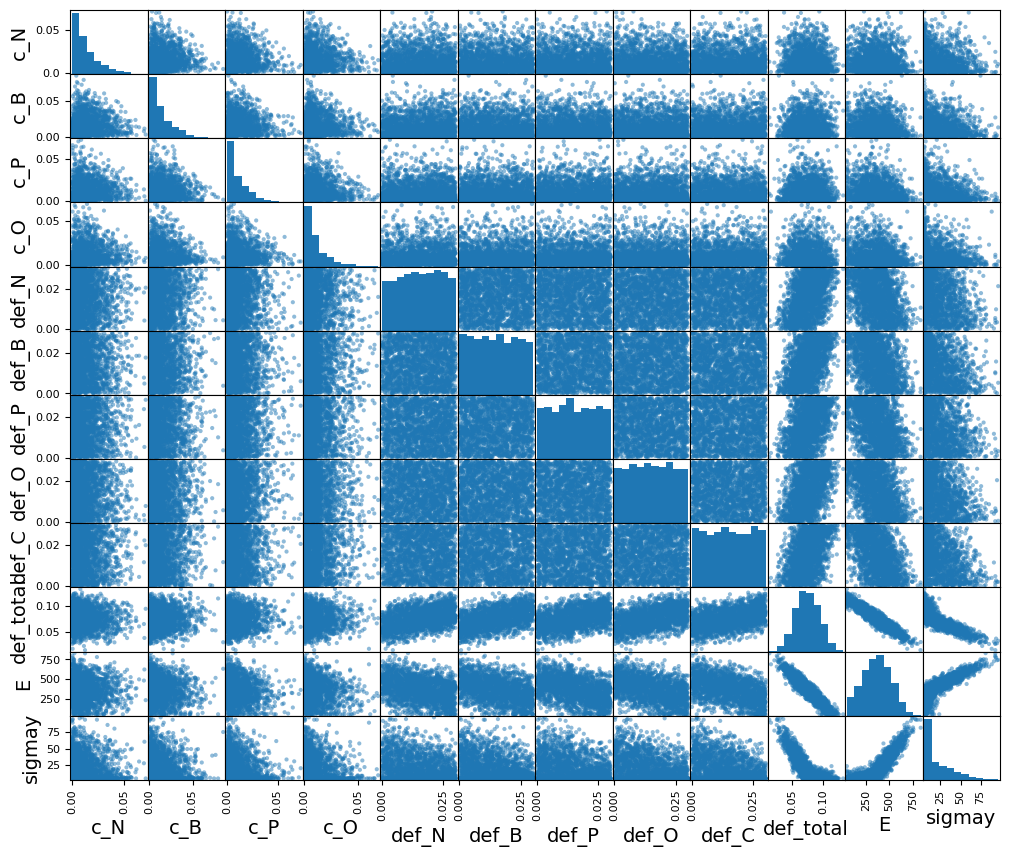

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(DopDef, figsize=(12, 10))
plt.show()

### Normalizing and Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to normalize
columns_to_normalize = ['E', 'sigmay', 'def_N', 'def_B', 'def_P', 'def_O', 'def_C', 'def_total']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected columns
DopDef[columns_to_normalize] = scaler.fit_transform(DopDef[columns_to_normalize])

# Display the head of the DataFrame to show the normalized columns
display(DopDef.head())

,c_N,c_B,c_P,c_O,def_N,def_B,def_P,def_O,def_C,def_total,E,sigmay
0,0.032454,0.005138,0.015816,0.010288,-1.099065,0.946504,0.526709,-0.939163,1.179314,0.295146,-0.599881,-0.893028
1,0.014493,0.003999,0.003445,0.005042,1.214848,0.924632,-0.116909,1.344942,1.548723,2.214199,-1.760955,-0.893028
2,0.000671,0.001019,0.001260,0.001148,-1.540025,0.095933,1.529876,-0.773155,-1.534153,-0.998211,1.122827,1.657349
3,0.000123,0.000844,0.000236,0.000449,1.573540,-0.659138,-1.300651,-1.369386,-0.542485,-1.047953,1.456060,2.261825
4,0.002289,0.059057,0.017510,0.002471,1.194815,0.340429,-0.226151,-1.275494,1.355617,0.628357,-0.797838,-0.428343


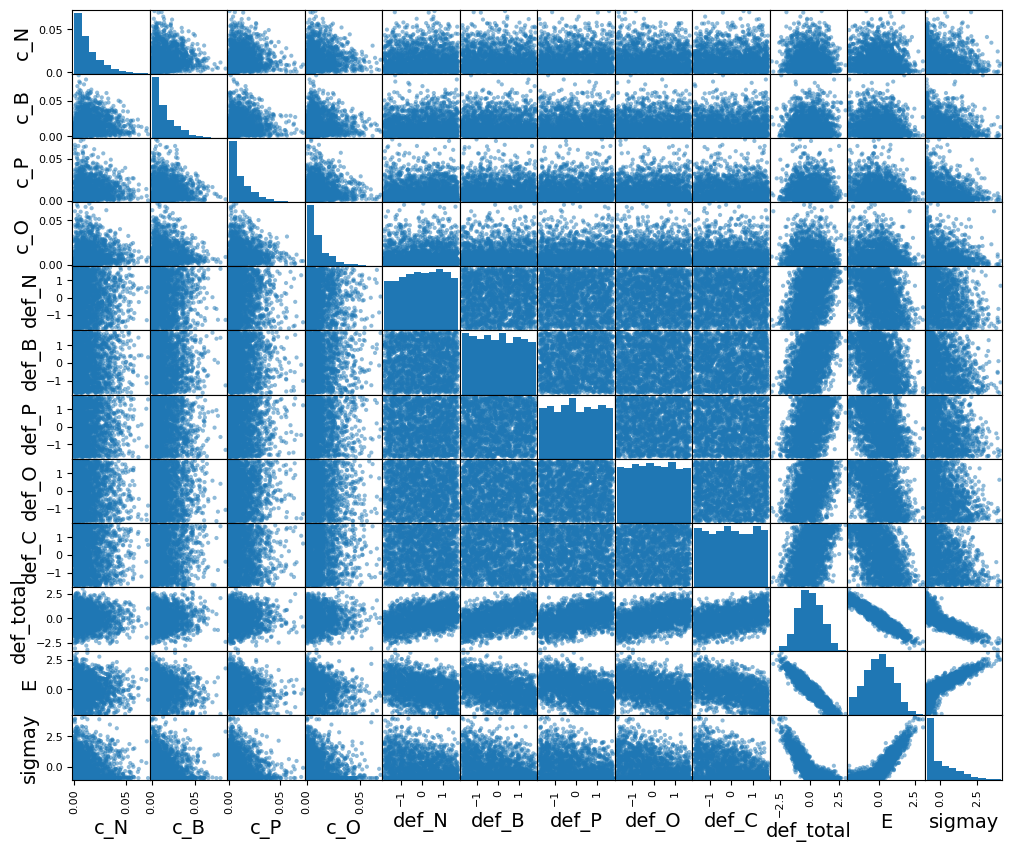

In [ ]:
corr_mat2 =DopDef.corr(numeric_only=True)
corr_mat2[['E', 'sigmay']].sort_values(by='E', ascending=True)
from pandas.plotting import scatter_matrix
scatter_matrix(DopDef, figsize=(12, 10))
plt.show()

## Create a Test Set

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(DopDef, test_size=0.2, random_state=42)

# Prepare the Data for Machine Learning Algorithms

In [ ]:
DD = train_set.drop("E", axis=1)
DD_labels = train_set["E"].copy()

## Data Cleaning

We missed it


## Handling Text and Categorical Attributes

We missed it


## Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
DD_min_max_scaled = min_max_scaler.fit_transform(DD)

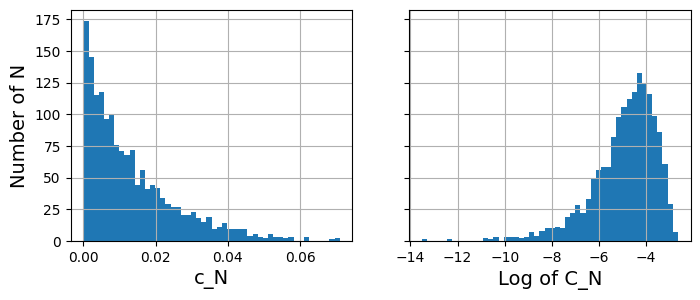

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
DD["c_N"].hist(ax=axs[0], bins=50)
DD["c_N"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("c_N")
axs[1].set_xlabel("Log of C_N")
axs[0].set_ylabel("Number of N")
plt.show()

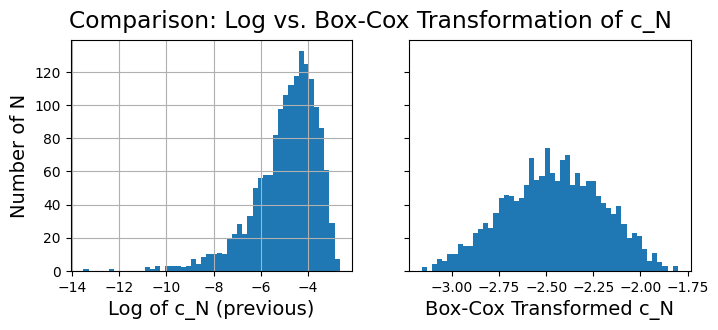

In [ ]:
from sklearn.preprocessing import power_transform
import numpy as np
import matplotlib.pyplot as plt

# Reshape the 'c_N' series to a 2D array as required by power_transform
c_N_reshaped = DD["c_N"].values.reshape(-1, 1)

# Apply Box-Cox transformation. It requires strictly positive data.
# If data contains zeros or negative values, a small constant might be added,
# but 'c_N' appears to be positive based on previous outputs.
# The 'method="box-cox"' specifies the Box-Cox transformation.
c_N_boxcox_transformed = power_transform(c_N_reshaped, method='box-cox', standardize=False)

# Plot the histogram of the Box-Cox transformed 'c_N'
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
DD["c_N"].apply(np.log).hist(ax=axs[0], bins=50)
axs[0].set_xlabel("Log of c_N (previous)")
axs[0].set_ylabel("Number of N")

axs[1].hist(c_N_boxcox_transformed, bins=50)
axs[1].set_xlabel("Box-Cox Transformed c_N")
plt.suptitle("Comparison: Log vs. Box-Cox Transformation of c_N")
plt.show()

The Box-Cox transformation aims to make the data as close to a normal distribution as possible. By comparing its histogram with the previously obtained logarithmic distribution, you can visually assess if it provides a better normalization for `c_N`.

## Transformation Pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In [ ]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [ ]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
DD_num_prepared = num_pipeline.fit_transform(DD)
DD_num_prepared[:2].round(2)

array([[ 1.59,  0.16,  0.05, -0.35, -0.26,  1.22,  0.7 , -0.52, -0.43,
         0.32, -0.15],
       [-0.71, -0.37, -0.76, -0.79,  1.47,  1.24,  0.64, -0.53,  1.22,
         1.83, -0.43]])

In [ ]:
def monkey_patch_get_signature_names_out():
    """Monkey patch some classes which did not handle get_feature_names_out()
       correctly in Scikit-Learn 1.0.*."""
    from inspect import Signature, signature, Parameter
    import pandas as pd
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline, Pipeline
    from sklearn.preprocessing import FunctionTransformer, StandardScaler

    default_get_feature_names_out = StandardScaler.get_feature_names_out

    if not hasattr(SimpleImputer, "get_feature_names_out"):
      print("Monkey-patching SimpleImputer.get_feature_names_out()")
      SimpleImputer.get_feature_names_out = default_get_feature_names_out

    if not hasattr(FunctionTransformer, "get_feature_names_out"):
        print("Monkey-patching FunctionTransformer.get_feature_names_out()")
        orig_init = FunctionTransformer.__init__
        orig_sig = signature(orig_init)

        def __init__(*args, feature_names_out=None, **kwargs):
            orig_sig.bind(*args, **kwargs)
            orig_init(*args, **kwargs)
            args[0].feature_names_out = feature_names_out

        __init__.__signature__ = Signature(
            list(signature(orig_init).parameters.values()) + [
                Parameter("feature_names_out", Parameter.KEYWORD_ONLY)])

        def get_feature_names_out(self, names=None):
            if callable(self.feature_names_out):
                return self.feature_names_out(self, names)
            assert self.feature_names_out == "one-to-one"
            return default_get_feature_names_out(self, names)

        FunctionTransformer.__init__ = __init__
        FunctionTransformer.get_feature_names_out = get_feature_names_out

monkey_patch_get_signature_names_out()

In [ ]:
df_DD_num_prepared = pd.DataFrame(
    DD_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=DD.index)

In [ ]:
num_pipeline.set_params(simpleimputer__strategy="median")

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [ ]:
import numpy as np
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
)

In [ ]:
DD_prepared = preprocessing.fit_transform(DD)
DD_prepared.shape

(1600, 11)

In [ ]:
preprocessing.get_feature_names_out()

array(['pipeline__c_N', 'pipeline__c_B', 'pipeline__c_P', 'pipeline__c_O',
       'pipeline__def_N', 'pipeline__def_B', 'pipeline__def_P',
       'pipeline__def_O', 'pipeline__def_C', 'pipeline__def_total',
       'pipeline__sigmay'], dtype=object)

# Select and Train a Model

## Training and Evaluating on the Training Set

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(DD, DD_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7af8065d0f80>)])),
                ('linearregression', LinearRegression())])

In [ ]:
import pandas as pd

# Get the LinearRegression model from the pipeline
linear_model = lin_reg.named_steps['linearregression']

coeffs = linear_model.coef_
intercept = linear_model.intercept_

# Get feature names from the preprocessing step
features = lin_reg.named_steps['columntransformer'].get_feature_names_out()

equation = "y = "

for feature, coef in zip(features, coeffs):
    equation += f"{coef:.4f} * {feature} + "

equation += f"{intercept:.4f}"

print(equation)

y = -0.0526 * pipeline__c_N + -0.0855 * pipeline__c_B + -0.1442 * pipeline__c_P + -0.1684 * pipeline__c_O + -0.1438 * pipeline__def_N + -0.1784 * pipeline__def_B + -0.2103 * pipeline__def_P + -0.2446 * pipeline__def_O + -0.2566 * pipeline__def_C + -0.4660 * pipeline__def_total + 0.0160 * pipeline__sigmay + 0.0060


Let's try the full preprocessing pipeline on a few training instances:

In [ ]:
DD_predictions = lin_reg.predict(DD)
print(DD_predictions[:5] )
print(DD_labels.iloc[:5].values)

[-0.27854225 -1.2954147  -0.55786684 -0.26124594  0.02317457]
[-0.3866744  -1.11818093 -0.6090324   0.02865074 -0.20818526]


In [ ]:
# extra code – computes the error ratios
error_ratios = DD_predictions[:5] / DD_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-28.0%, 15.9%, -8.4%, -1011.8%, -111.1%


In [ ]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(DD_labels, DD_predictions)
lin_rmse

0.2091715279034713

## Evaluating the Model on the Test Set

In [ ]:
# Separate features (DD_test) and labels (DD_test_labels) from the test set
DD_test = test_set.drop("E", axis=1)
DD_test_labels = test_set["E"].copy()

# Make predictions on the test set
DD_test_predictions = lin_reg.predict(DD_test)

# Calculate the RMSE on the test set
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

test_rmse = root_mean_squared_error(DD_test_labels, DD_test_predictions)

print(f"Linear Regression RMSE on Test Set: {test_rmse}")

Linear Regression RMSE on Test Set: 0.21832016903526336


### Cross-Validation for Linear Regression

Cross-validation is a technique to evaluate predictive models by partitioning the original sample into a training set to train the model, and a test set to evaluate it. It helps to assess how the model will generalize to an independent data set.

In [ ]:
from sklearn.model_selection import cross_val_score

# Use cross_val_score to evaluate the linear regression model
# The scoring metric 'neg_root_mean_squared_error' is used because cross_val_score returns negative values
# We take the absolute value to get the RMSE.
lin_reg_rmse_scores = -cross_val_score(lin_reg, DD, DD_labels, cv=10,
                                         scoring="neg_root_mean_squared_error")

print("Linear Regression RMSE Scores:", lin_reg_rmse_scores)
print("Mean RMSE:", lin_reg_rmse_scores.mean())
print("Standard deviation of RMSE:", lin_reg_rmse_scores.std())

Linear Regression RMSE Scores: [0.21626191 0.20326881 0.22176811 0.21235548 0.1980365  0.1984313
 0.21513218 0.19793667 0.23048048 0.21217109]
Mean RMSE: 0.21058425250654408
Standard deviation of RMSE: 0.010479174086684567


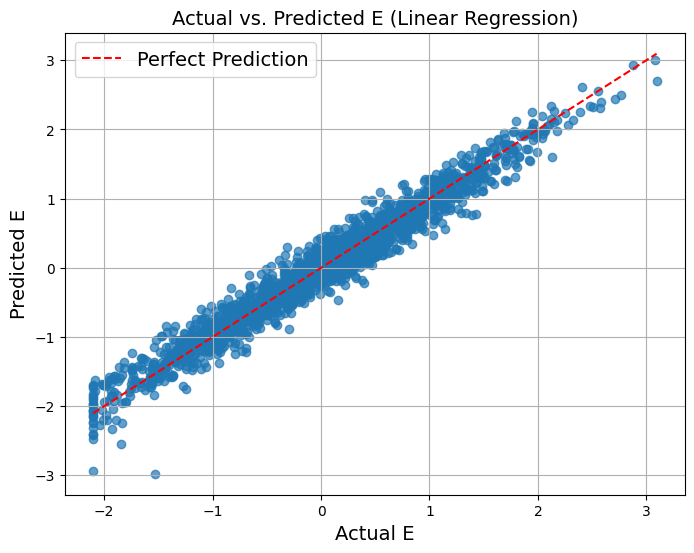

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(DD_labels, DD_predictions, alpha=0.7)
plt.plot([min(DD_labels), max(DD_labels)], [min(DD_labels), max(DD_labels)], 'r--', label='Perfect Prediction') # Add a perfect prediction line
plt.xlabel("Actual E")
plt.ylabel("Predicted E")
plt.title("Actual vs. Predicted E (Linear Regression)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Separate features (DD_test) and labels (DD_test_labels) from the test set
DD_test = test_set.drop("E", axis=1)
DD_test_labels = test_set["E"].copy()

# Make predictions on the test set
DD_test_predictions = lin_reg.predict(DD_test)

# Calculate the RMSE on the test set
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

test_rmse = root_mean_squared_error(DD_test_labels, DD_test_predictions)

print(f"Linear Regression RMSE on Test Set: {test_rmse}")

Linear Regression RMSE on Test Set: 0.21832016903526336


To determine if an **RMSE of 0.2183 is 'good' or 'bad'**, we need to consider it within context:

Scale of the Target Variable: Your target variable 'E' was normalized using StandardScaler. This means its original scale was transformed to have a mean of 0 and a standard deviation of 1. An RMSE of 0.2183 on this standardized scale indicates that, on average, your predictions are off by about 0.218 standard deviations from the actual values.

Comparison to Training and Cross-Validation RMSE: We previously calculated:

**Training RMSE: 0.2091**
**Mean Cross-Validation RMSE: 0.2105**
The test RMSE (0.2183) is very **close to both the training RMSE and the cross-validation RMSE**. This is a good indication because it suggests that your model is generalizing well to new, unseen data and is not significantly overfitting the training data.

Absolute Value: An RMSE close to zero is ideal. While 0.2183 isn't zero, for a normalized variable, this is generally considered a good result. It implies that your linear regression model is making reasonably accurate predictions on the Young's Modulus (E) given the features.

In summary, based on the consistency of the RMSE across different datasets and the normalized scale of your target variable, an RMSE of 0.2183 is a good performance for your linear regression model.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(DD, DD_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a0ef68b79e0>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
DD_predictions = tree_reg.predict(DD)
tree_rmse = root_mean_squared_error(DD_labels, DD_predictions)
tree_rmse

0.0